In [76]:
## build intuitive sample data set, test with architecture

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Fully supervised, 2 distributions

Total X shape: (1000, 2)
Total y shape: (1000, 1)
            p1         p2  label
0     5.716599   3.704072    0.0
1    15.928369  13.324982    0.0
2     4.579026 -14.101247    0.0
3   -16.607294   1.663731    0.0
4     6.054668  -2.667300    0.0
..         ...        ...    ...
995   0.528348  -3.063652    1.0
996   9.236141  -3.767040    0.0
997 -16.210936 -10.934278    0.0
998  18.543547  14.392286    0.0
999  -6.508796  -0.164134    0.0

[1000 rows x 3 columns]


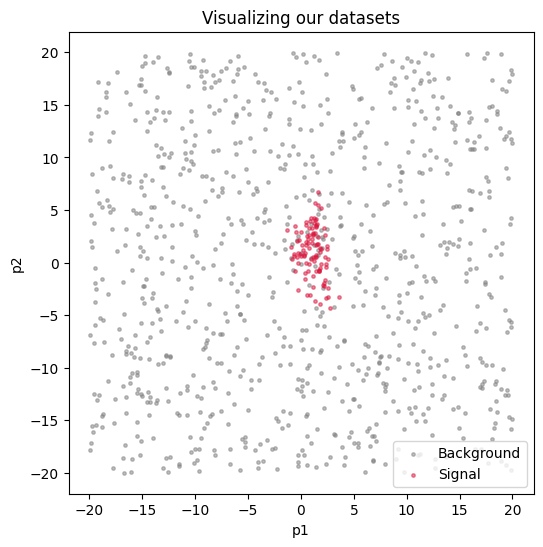

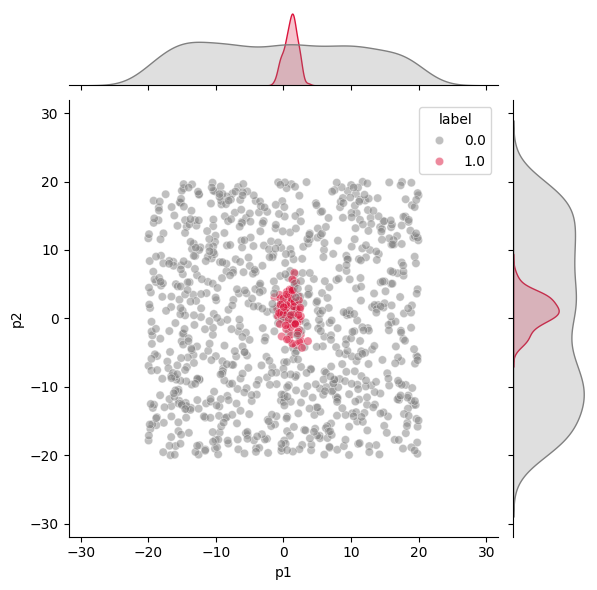

In [ ]:
# 1000 data points, 900 flat, 100 peaked (anomaly)

background_events = 900
signal_events = 100

# background distribution
x_b = np.random.uniform(low=-20, high=20, size=(background_events, 2))
y_b = np.zeros((background_events, 1), dtype=np.float32)

# signal distribution
mu_s = np.array([1.0, 1.0])
cov_s = np.array([[1.0, -0.3], 
                  [-0.3, 5.0]])
x_s = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
y_s = np.ones((signal_events, 1), dtype=np.float32)

# combine into one dataset
X = np.vstack([x_b, x_s]).astype(np.float32)
y = np.concatenate((y_b, y_s)).astype(np.float32)

### Put these together and shuffle
idx = np.random.permutation(len(X))
X = X[idx] # inputs
y = y[idx] # labels

print(f"Total X shape: {X.shape}") # should be (1000, 2) (1000 data points with 2 features each)
print(f"Total y shape: {y.shape}") # should be (1000,) (1000 labels, one for each data point)

df = pd.DataFrame(np.column_stack([X,y]), columns = ["p1", "p2", "label"])
print(df)

plt.figure(figsize=(6,6))
plt.scatter(df[df.label != True].p1, df[df.label != True].p2, s=6, color="grey", alpha=0.5, label="Background")
plt.scatter(df[df.label == True].p1, df[df.label == True].p2, s=6, color="crimson", alpha=0.5, label="Signal")
plt.legend()
plt.title("Visualizing our datasets")
plt.xlabel('p1'); plt.ylabel('p2')
plt.show()


# This creates a scatter plot in the middle, but adds density curves (the peaks!) on the top and side axes
sns.jointplot(data=df, x="p1", y="p2", hue="label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [ ]:
# define model architecture

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 2, hidden_dim1 = 128, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                          
            nn.Linear(hidden_dim1, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

In [79]:
# split data into training, validation, and test sets

X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5)

print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 700 events.
Validation set has 150 events.
Test set has 150 events.


In [80]:
# standardize the data
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_scaled = scaler.fit_transform(X_train)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

Train mean (before scaling): [-0.2928037  -0.39308357]
Train mean (after scaling) -- each dimension should be close to 0: [-7.578305e-09  7.663455e-09]
Train std (before scaling) [11.101033 11.171858]
Train std (after scaling) -- each dimension should be close to 1: [0.9999998 0.9999998]


In [81]:
# create tensors for datasets

X_train_scaled_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_val_scaled_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

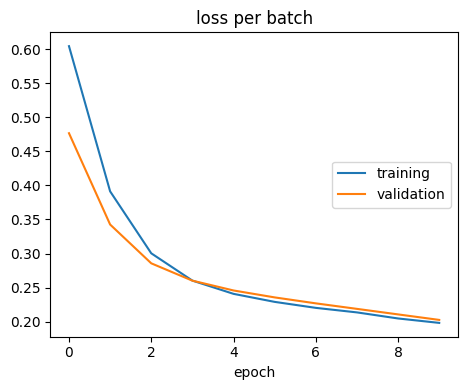

loss per batch
	training         	 (min:    0.198, max:    0.605, cur:    0.198)
	validation       	 (min:    0.202, max:    0.477, cur:    0.202)
Epoch 9, Loss: 0.17742455005645752
[array([[0.00582119],
       [0.10421228],
       [0.018021  ],
       [0.14099997],
       [0.01960272],
       [0.00734947],
       [0.00557515],
       [0.02968636],
       [0.02008561],
       [0.04025517],
       [0.0187842 ],
       [0.18063292],
       [0.11813402],
       [0.21124874],
       [0.06540548],
       [0.04599237],
       [0.02468884],
       [0.14967357],
       [0.2260563 ],
       [0.05317422],
       [0.08157191],
       [0.07262386],
       [0.09359808],
       [0.06791544],
       [0.01786176],
       [0.03628536],
       [0.22111419],
       [0.10233612],
       [0.21815364],
       [0.21585107],
       [0.01250272],
       [0.10547885]], dtype=float32), array([[0.02557267],
       [0.09103338],
       [0.05345617],
       [0.22248362],
       [0.19762872],
       [0.081328  ],
  

In [82]:
# training loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 2, hidden_dim1 = 128, hidden_dim2 = 128, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch


    # validation
    model.eval()
    total_val_loss = 0
    all_out = []
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()
        all_out.append(out.detach().cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(all_out)

In [83]:
# test accuracy

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        predicted = (out >= 0.5).float()
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.2806 | Test accuracy: 0.847


# WRONG: test labels should still be regions not true 

# Weakly supervised, regions

In [84]:
# 1000 data points, 900 flat, 100 peaked (anomaly)

background_events = 900
signal_events = 100

# background distribution
x_b = np.random.uniform(low=-20, high=20, size=(background_events, 2))
x_b = np.array(x_b, dtype=np.float32)

# split background data into train/val (85% of the data) and test sets (15% of the data)
indices_b = np.arange(len(x_b))
np.random.seed(42)
np.random.shuffle(indices_b)
split_idx = int(len(x_b) * 0.8)
trainval_indices_b, test_indices_b = indices_b[:split_idx], indices_b[split_idx:]
x_trainval_b = x_b[trainval_indices_b]
x_test_b = x_b[test_indices_b]

indices_b2 = np.arange(len(x_trainval_b))
np.random.seed(42)
np.random.shuffle(indices_b2)
split_idx_trainval = int(len(x_trainval_b) * 0.75)
train_indices_b, val_indices_b = indices_b2[:split_idx_trainval], indices_b2[split_idx_trainval:]
x_train_b = x_trainval_b[train_indices_b]
x_val_b = x_trainval_b[val_indices_b]


# signal distribution
mu_s = np.array([1.0, 1.0])
cov_s = np.array([[1.0, -0.3], 
                  [-0.3, 5.0]])
x_s = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
x_s = np.array(x_s, dtype=np.float32)


# split signal data into train/val (85% of the data) and test sets (15% of the data)
indices_s = np.arange(len(x_s))
np.random.seed(42)
np.random.shuffle(indices_s)
split_idx = int(len(x_s) * 0.8)
trainval_indices_s, test_indices_s = indices_s[:split_idx], indices_s[split_idx:]
x_trainval_s = x_s[trainval_indices_s]
x_test_s = x_s[test_indices_s]

indices_s2 = np.arange(len(x_trainval_s))
np.random.seed(42)
np.random.shuffle(indices_s2)
split_idx_trainval = int(len(x_trainval_s) * 0.75)
train_indices_s, val_indices_s = indices_s2[:split_idx_trainval], indices_s2[split_idx_trainval:]
x_train_s = x_trainval_s[train_indices_s]
x_val_s = x_trainval_s[val_indices_s]

x_train = np.vstack([x_train_b, x_train_s])
x_val = np.vstack([x_val_b, x_val_s])

x_train_background_region = []
x_train_signal_region = []
x_val_background_region = []
x_val_signal_region = []
for point in x_train:
    if point[0] < -10 or point[0] > 10:
        x_train_background_region.append(point)
    else:
        x_train_signal_region.append(point)
for point in x_val:
    if point[0] < -10 or point[0] > 10:
        x_val_background_region.append(point)
    else:
        x_val_signal_region.append(point)


x_train_background_region = np.array(x_train_background_region)
x_train_signal_region = np.array(x_train_signal_region)
x_val_background_region = np.array(x_val_background_region)
x_val_signal_region = np.array(x_val_signal_region)

y_train_background_region = np.zeros((len(x_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(x_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(x_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(x_val_signal_region), 1), dtype=np.float32)

X_train = np.vstack([x_train_background_region, x_train_signal_region]).astype(np.float32)
X_val = np.vstack([x_val_background_region, x_val_signal_region]).astype(np.float32)
y_train = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")


# in test set, label points with true labels (for evaluation)
y_test_b = np.zeros((len(x_test_b), 1), dtype=np.float32)
y_test_s = np.ones((len(x_test_s), 1), dtype=np.float32)

X_test = np.vstack([x_test_b, x_test_s]).astype(np.float32)
y_test = np.concatenate((y_test_b, y_test_s)).astype(np.float32)

print(f"Test set has {len(X_test)} events.")


Training set has 600 events.
Validation set has 200 events.
Test set has 200 events.


            p1         p2  weak label
0   -10.610370  18.496201         0.0
1   -16.786995  -2.915357         0.0
2   -14.096929  -0.462690         0.0
3   -15.825933  -5.706830         0.0
4   -10.470820  17.078014         0.0
..         ...        ...         ...
595   0.102440   2.660611         1.0
596   1.559453   0.073610         1.0
597   2.623372   5.608932         1.0
598   1.324603   0.111193         1.0
599   3.067806   4.936246         1.0

[600 rows x 3 columns]


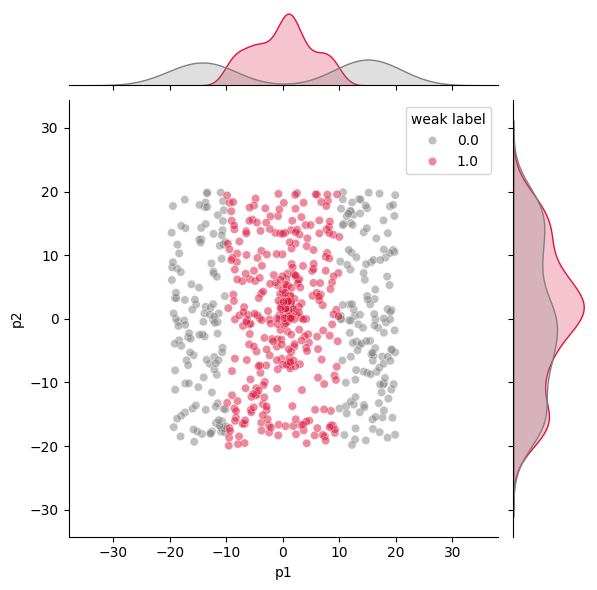

In [85]:
df = pd.DataFrame(np.column_stack([X_train, y_train]), columns = ["p1", "p2", "weak label"])
print(df)

# This creates a scatter plot in the middle, but adds density curves (the peaks!) on the top and side axes
sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [86]:
### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_scaled = scaler.fit_transform(X_train)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

Train mean (before scaling): [0.45348108 0.12679902]
Train mean (after scaling) -- each dimension should be close to 0: [2.0116568e-08 8.1956388e-09]
Train std (before scaling) [10.733432 11.026357]
Train std (after scaling) -- each dimension should be close to 1: [0.99999994 0.99999994]


In [87]:
X_train_scaled_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_val_scaled_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [88]:
for x_batch, y_batch in test_loader:
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([32, 2]) torch.Size([32, 1])


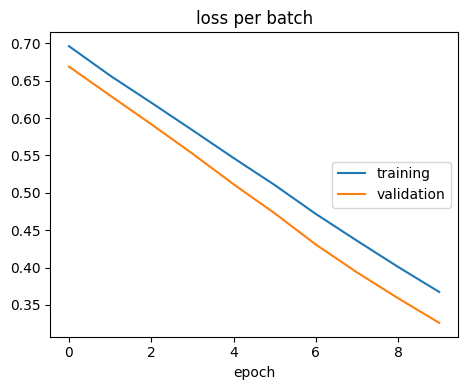

loss per batch
	training         	 (min:    0.367, max:    0.696, cur:    0.367)
	validation       	 (min:    0.326, max:    0.669, cur:    0.326)
Epoch 9, Loss: 0.22370502352714539
[array([[0.2663646 ],
       [0.1291576 ],
       [0.50436765],
       [0.3841108 ],
       [0.3267351 ],
       [0.13503498],
       [0.28630584],
       [0.12444962],
       [0.18863554],
       [0.33620128],
       [0.17383875],
       [0.15763222],
       [0.3800212 ],
       [0.4325225 ],
       [0.2423374 ],
       [0.12728122],
       [0.09999828],
       [0.19914629],
       [0.2115889 ],
       [0.44453192],
       [0.13326132],
       [0.46533278],
       [0.41896552],
       [0.37366477],
       [0.35763806],
       [0.28200567],
       [0.3636484 ],
       [0.08098638],
       [0.5118444 ],
       [0.4389645 ],
       [0.20562068],
       [0.34132826]], dtype=float32), array([[0.35827237],
       [0.42711517],
       [0.18995112],
       [0.3439654 ],
       [0.42067593],
       [0.30563524],
  

In [89]:
# training loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 2, hidden_dim1 = 128, hidden_dim2 = 128, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch


    # validation
    model.eval()
    total_val_loss = 0
    all_out = []
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()
        all_out.append(out.detach().cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(all_out)

In [90]:
# gauge accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out >= 0.5).float()
        all_scores.extend(out.squeeze().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.7145 | Test accuracy: 0.555


In [ ]:
# gauge accuracy on test data set
# ROC shows binary classification performance, AUC is area under that curve, represents ability to distinguish between signal/background regions

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_labels, all_scores)
print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")

Test ROC-AUC (vs true labels): 0.956  (0.5 = no separation, 1.0 = perfect)


## ****better way to split up data for weakly supervised

In [92]:
# try set division again

background_events = 900
signal_events = 100

# background distribution
Xb = np.random.uniform(low=-20, high=20, size=(background_events, 2))
Xb = np.array(x_b, dtype=np.float32)
yb = np.zeros((len(x_b), 1), dtype=np.float32)


Xb_train, Xb_valtest, yb_train, yb_valtest = train_test_split(Xb, yb, test_size = 0.3)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(Xb_valtest, yb_valtest, test_size=0.5)


# signal distribution
mu_s = np.array([1.0, 1.0])
cov_s = np.array([[1.0, -0.3], 
                  [-0.3, 5.0]])
Xs = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
Xs = np.array(x_s, dtype=np.float32)
ys = np.ones((len(x_s), 1), dtype=np.float32)

Xs_train, Xs_valtest, ys_train, ys_valtest = train_test_split(Xs, ys, test_size = 0.3)
Xs_val, Xs_test, ys_val, ys_test = train_test_split(Xs_valtest, ys_valtest, test_size=0.5)

# guarantees that training, validation, and test have the same percentage of background vs signal points (90/10)
print(f"Background training set has {len(Xb_train)} events.")
print(f"Background validation set has {len(Xb_val)} events.")
print(f"Background test set has {len(Xb_test)} events.")
print(f"Signal training set has {len(Xs_train)} events.")
print(f"Signal validation set has {len(Xs_val)} events.")
print(f"Signal test set has {len(Xs_test)} events.")

X_train = np.vstack([Xb_train, Xs_train])
X_val = np.vstack([Xb_val, Xs_val])
X_test = np.vstack([Xb_test, Xs_test])
y_train = np.concatenate([yb_train, ys_train])
y_val = np.concatenate([yb_val, ys_val])
y_test = np.concatenate([yb_test, ys_test])

idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.random.permutation(len(X_val))
X_val = X_val[idx]
y_val = y_val[idx]

idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

Background training set has 630 events.
Background validation set has 135 events.
Background test set has 135 events.
Signal training set has 70 events.
Signal validation set has 15 events.
Signal test set has 15 events.


In [93]:
# keep test set the same, remove labels from train/validation and add region labels
# inner region is -5 to 5 rather than -10 to 10

X_train_background_region = []
X_train_signal_region = []
X_val_background_region = []
X_val_signal_region = []

for point in X_train:
    if point[0] < -5 or point[0] > 5:
        X_train_background_region.append(point)
    else:
        X_train_signal_region.append(point)
for point in X_val:
    if point[0] < -5 or point[0] > 5:
        X_val_background_region.append(point)
    else:
        X_val_signal_region.append(point)

X_train_background_region = np.array(X_train_background_region)
X_train_signal_region = np.array(X_train_signal_region)
X_val_background_region = np.array(X_val_background_region)
X_val_signal_region = np.array(X_val_signal_region)

y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

X_train_weak = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
X_val_weak = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
y_train_weak = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val_weak = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train_weak)} events.")
print(f"Validation set has {len(X_val_weak)} events.")
print(f"Test set has {len(X_test)} events.")


Training set has 700 events.
Validation set has 150 events.
Test set has 150 events.


            p1         p2  weak label
0   -17.555956   1.547294         0.0
1   -14.471989  14.297085         0.0
2    -8.017515 -14.924741         0.0
3    -9.887710  19.397051         0.0
4    12.884154  -5.780525         0.0
..         ...        ...         ...
695   0.089841   2.371691         1.0
696  -2.328622  14.119245         1.0
697   1.487554  -3.170451         1.0
698   0.031914 -13.301942         1.0
699   2.040523  -3.967118         1.0

[700 rows x 3 columns]


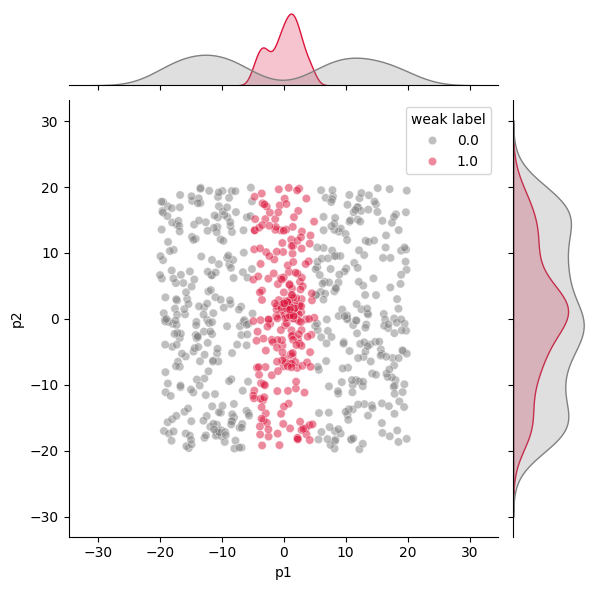

In [94]:
## visualize the regions

df = pd.DataFrame(np.column_stack([X_train_weak, y_train_weak]), columns = ["p1", "p2", "weak label"])
print(df)

# This creates a scatter plot in the middle, but adds density curves (the peaks!) on the top and side axes
sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [95]:
### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_weak_scaled = scaler.fit_transform(X_train_weak)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_weak_scaled   = scaler.transform(X_val_weak)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train_weak.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_weak_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train_weak.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_weak_scaled.std(axis=0))

Train mean (before scaling): [-0.3877573   0.25837356]
Train mean (after scaling) -- each dimension should be close to 0: [-1.1090721e-08  1.6817024e-08]
Train std (before scaling) [10.862088 11.052237]
Train std (after scaling) -- each dimension should be close to 1: [1.0000001 1.       ]


In [96]:
X_train_weak_scaled_tensor = torch.tensor(X_train_weak_scaled)
y_train_weak_tensor = torch.tensor(y_train_weak)

X_val_weak_scaled_tensor = torch.tensor(X_val_weak_scaled)
y_val_weak_tensor = torch.tensor(y_val_weak)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_weak_dataset = TensorDataset(X_train_weak_scaled_tensor, y_train_weak_tensor)
val_weak_dataset = TensorDataset(X_val_weak_scaled_tensor, y_val_weak_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_weak_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_weak_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

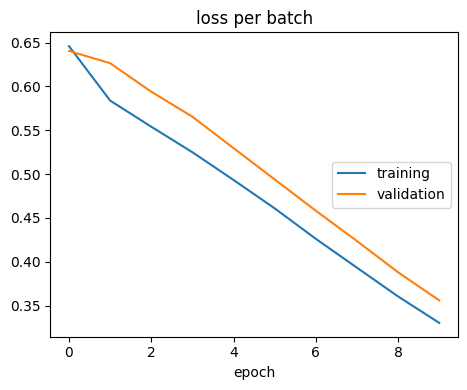

loss per batch
	training         	 (min:    0.330, max:    0.646, cur:    0.330)
	validation       	 (min:    0.356, max:    0.640, cur:    0.356)
Epoch 9, Loss: 0.5131516456604004
[array([[0.07758527],
       [0.13541923],
       [0.23568511],
       [0.20217422],
       [0.362487  ],
       [0.29829964],
       [0.1017082 ],
       [0.0227552 ],
       [0.15258275],
       [0.2877344 ],
       [0.31768116],
       [0.49046475],
       [0.2505203 ],
       [0.07027348],
       [0.4474204 ],
       [0.14628667],
       [0.06277792],
       [0.15793127],
       [0.15933208],
       [0.33832672],
       [0.2782081 ],
       [0.0506261 ],
       [0.18171142],
       [0.08111357],
       [0.09097756],
       [0.0388864 ],
       [0.27112877],
       [0.02636237],
       [0.03726455],
       [0.08299524],
       [0.4184382 ],
       [0.21081866]], dtype=float32), array([[0.27466056],
       [0.23060583],
       [0.47734615],
       [0.13397792],
       [0.17492415],
       [0.32380918],
   

In [97]:
# training loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 2, hidden_dim1 = 128, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch


    # validation
    model.eval()
    total_val_loss = 0
    all_out = []
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()
        all_out.append(out.detach().cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(all_out)

In [98]:
# gauge accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out >= 0.5).float()
        all_scores.extend(out.squeeze().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.3359 | Test accuracy: 0.847


In [99]:
auc = roc_auc_score(all_labels, all_scores)
print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")

Test ROC-AUC (vs true labels): 0.997  (0.5 = no separation, 1.0 = perfect)


## De-correlated inputs ???